# HH2 - Step 3: Temperature Model (Random Forests)

## Algorithm curent plan:
- Predict indoor temperatures from outdoor temperatures (forecasts), sunlight (forecasts), and window states (loop over all possibilities?)
> Random Forest ML model

- Predict 'presets' for the sensors:
> Designerly Baseline Model

### Import libraries 

In [1]:
#Pandas is a software library written for the Python programming language for data manipulation and analysis.
import pandas as pd
pd.options.mode.chained_assignment = None  # default='warn' ## disable chained assignment warnings due to false positives
#NumPy is a library for the Python programming language, adding support for large, multi-dimensional arrays and matrices, along with a large collection of high-level mathematical functions to operate on these arrays
import numpy as np
# Matplotlib is a plotting library for python and pyplot gives us a MatLab like plotting framework. We will use this in our plotter function to plot data.
import matplotlib.pyplot as plt
#Seaborn is a Python data visualization library based on matplotlib. It provides a high-level interface for drawing attractive and informative statistical graphics
import seaborn as sns
#Plotly is a Python data visualization library 
import plotly.graph_objects as go
import plotly.express as px
import datetime as dt
import warnings

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score  # Import metrics
from sklearn.ensemble import RandomForestRegressor

### Load and view data 

# Model to decide which action to take (door, window, curtain)
## Attempt 1/2 (categorical)

In [1019]:
## BASELINE MODEL (mean prediction)
# Load your data
database_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_merged.csv")
database_hourly['ts'] = pd.to_datetime(database_hourly['ts'])  # Specify the correct format
database_hourly.drop(['weather_main', 'weather_description', 'shade_left', 'shade_right', 'curtain_left', 'curtain_right'], axis=1, inplace=True)
### Turn distance value into bool value (open/closed)
threshold = 50  # Define a threshold for distance
database_hourly['distance_left_open'] = database_hourly['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database_hourly['distance_right_open'] = database_hourly['distance_right'] > threshold  # True if distance_right is greater than threshold, else False
database_hourly.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
database_hourly['window_door'] = database['window_door'].replace({0.0: False, 1.0: True})
database_hourly['door'] = database_hourly['door'].replace({0.0: False, 1.0: True})

df = database_hourly

# Filter the DataFrame to get only the last two weeks of data
end_date = df['ts'].max()  # Get the maximum date in the DataFrame
start_date = end_date - pd.Timedelta(weeks=2)  # Calculate the start date for the last two weeks
df = df[(df['ts'] >= start_date) & (df['ts'] <= end_date)]  # Filter the DataFrame for the last two weeks

df

,ts,Temperature_indoor,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,window_door,light_right,light_left,Temperature_outdoor,door,hr,date,distance_left_open,distance_right_open
2732,2024-09-17 01:30:00,22.000000,12.4,13.9,11.5,NaN,0.0,NaN,12.8750,False,1,2024-09-17,False,False
2733,2024-09-17 01:40:00,22.000000,12.4,13.9,11.5,NaN,0.0,NaN,12.8750,False,1,2024-09-17,False,False
2734,2024-09-17 01:50:00,22.000000,12.4,13.9,11.5,NaN,0.0,NaN,12.8750,False,1,2024-09-17,False,False
2735,2024-09-17 02:00:00,22.000000,12.2,13.9,11.0,NaN,0.0,NaN,13.4375,False,2,2024-09-17,False,False
2736,2024-09-17 02:10:00,22.000000,12.1,13.9,11.0,NaN,0.0,NaN,13.4375,False,2,2024-09-17,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4739,2024-10-01 00:50:00,19.290000,13.8,14.4,12.9,NaN,0.0,NaN,13.3750,False,0,2024-10-01,False,False
4740,2024-10-01 01:00:00,19.220000,13.7,14.4,13.1,NaN,0.0,NaN,13.1875,False,1,2024-10-01,False,False
4741,2024-10-01 01:10:00,19.260000,13.8,14.4,12.8,NaN,0.0,NaN,13.1875,False,1,2024-10-01,False,False
4742,2024-10-01 01:20:00,19.300000,13.8,14.4,12.8,NaN,0.0,NaN,13.1875,False,1,2024-10-01,False,False


In [1023]:
## BASELINE MODEL (mean prediction)
# Load your data
database_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_merged.csv")
database_hourly['ts'] = pd.to_datetime(database_hourly['ts'])  # Specify the correct format
database_hourly.drop(['weather_main', 'shade_left', 'shade_right', 'curtain_left', 'curtain_right'], axis=1, inplace=True)
### Turn distance value into bool value (open/closed)
threshold = 50  # Define a threshold for distance
database_hourly['distance_left_open'] = database_hourly['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database_hourly['distance_right_open'] = database_hourly['distance_right'] > threshold  # True if distance_right is greater than threshold, else False
database_hourly.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
database_hourly['window_door'] = database['window_door'].replace({0.0: False, 1.0: True})
database_hourly['door'] = database_hourly['door'].replace({0.0: False, 1.0: True})

df = database_hourly

# Filter the DataFrame to get only the last two weeks of data
end_date = df['ts'].max()  # Get the maximum date in the DataFrame
start_date = end_date - pd.Timedelta(weeks=2)  # Calculate the start date for the last two weeks
df = df[(df['ts'] >= start_date) & (df['ts'] <= end_date)]  # Filter the DataFrame for the last two weeks



# Data preparation
df['date'] = pd.to_datetime(df['date'])
df = pd.get_dummies(df, columns=['weather_description'], drop_first=True)

# Create cumulative features for "window_door"
df['window_door'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['window_door'] = df['window_door'].astype(int)
df['window_open_duration'] = df['window_door'].groupby((df['window_door'] != df['window_door'].shift()).cumsum()).cumsum()  # Count consecutive open periods
df['window_closed_duration'] = (df['window_door'] == 0).astype(int)  # Create a binary column where 1 indicates the window is closed
df['window_closed_duration'] = df['window_closed_duration'].groupby((df['window_closed_duration'] != df['window_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# Create consecutive counts for 'door'
df['door'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['door'] = df['door'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
df['door_open_duration'] = df['door'].groupby((df['door'] != df['door'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
df['door_closed_duration'] = (df['door'] == 0).astype(int)  # Create a binary column for closed door
df['door_closed_duration'] = df['door_closed_duration'].groupby((df['door_closed_duration'] != df['door_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods for door

# Create consecutive counts for 'distance_left_open'
df['distance_left_open'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['distance_left_open'] = df['distance_left_open'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
df['distance_left_open_duration'] = df['distance_left_open'].groupby((df['distance_left_open'] != df['distance_left_open'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
df['distance_left_closed_duration'] = (df['distance_left_open'] == 0).astype(int)  # Create a binary column for closed door
df['distance_left_closed_duration'] = df['distance_left_closed_duration'].groupby((df['distance_left_closed_duration'] != df['distance_left_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# Create consecutive counts for 'distance_right_open'
df['distance_right_open'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
df['distance_right_open'] = df['distance_right_open'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
df['distance_right_open_duration'] = df['distance_right_open'].groupby((df['distance_right_open'] != df['distance_right_open'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
df['distance_right_closed_duration'] = (df['distance_right_open'] == 0).astype(int)  # Create a binary column for closed door
df['distance_right_closed_duration'] = df['distance_right_closed_duration'].groupby((df['distance_right_closed_duration'] != df['distance_right_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# # Calculate the average temperature of the last week\
# df['Temperature_indoor'] = df['Temperature_indoor'].round(2)
# # df['average_temperature_last'] = df['Temperature_indoor'].rolling(window=12).mean().shift(12)  # Calculate the rolling average of the last 12 hours
df['temperature_last'] = df['Temperature_indoor'].shift(12)  # get the temperature from 6 hours ago
# df['average_temperature_last'] = df['Temperature_indoor'].rolling(window=12).mean()  # Calculate the rolling average of the last 12 hours


# Remove rows with NaN values
df.dropna(inplace=True)  # This line removes any rows that contain NaN values

# Define features and target
X = df.drop(columns=['Temperature_indoor', 'date', 'ts', 'window_door', "door", 'distance_left_open', 'distance_right_open'])
y = df['Temperature_indoor']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)


# Assuming y_train is your training target variable and y_test is your test target variable

# Step 1: Calculate the mean of the training target variable
mean_prediction = np.mean(y_train)

# Step 2: Create predictions for the test set using the mean
y_pred_baseline = np.full_like(y_test, mean_prediction)

# Step 3: Evaluate the baseline model using MAE
baseline_mae = mean_absolute_error(y_test, y_pred_baseline)

print(f'Baseline MAE (Mean Prediction): {baseline_mae}')

Baseline MAE (Mean Prediction): 1.3605647748396965


In [108]:
# Load your data
database_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_hourly.csv")
database_hourly['ts'] = pd.to_datetime(database_hourly['ts'])  # Specify the correct format
database_hourly.drop(['weather_main', 'weather_main', 'shade_left', 'shade_right', 'curtain_left', 'curtain_right'], axis=1, inplace=True)
### Turn distance value into bool value (open/closed)
threshold = 50  # Define a threshold for distance
database_hourly['distance_left_open'] = database_hourly['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database_hourly['distance_right_open'] = database_hourly['distance_right'] > threshold  # True if distance_right is greater than threshold, else False
database_hourly.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
database_hourly = database_hourly.dropna(inplace = False)
database_hourly['window_door'] = database_hourly['window_door'].replace({0.0: False, 1.0: True})
database_hourly['door'] = database_hourly['door'].replace({0.0: False, 1.0: True})

df = database_hourly


# Filter the DataFrame to get only the last two weeks of data
end_date = df['ts'].max()  # Get the maximum date in the DataFrame
start_date = end_date - pd.Timedelta(weeks=2)  # Calculate the start date for the last two weeks
df = df[(df['ts'] >= start_date) & (df['ts'] <= end_date)]  # Filter the DataFrame for the last two weeks


# Data preparation
# df['date'] = pd.to_datetime(df['date']).astype('int64') / 10**9  # Convert to seconds since epoch
# df = pd.get_dummies(df, columns=['weather_main'], drop_first=False)
df = pd.get_dummies(df, columns=['weather_description'], drop_first=False)

# # Create cumulative features for "window_door"
# df['window_door'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
# df['window_door'] = df['window_door'].astype(int)
# df['window_open_duration'] = df['window_door'].groupby((df['window_door'] != df['window_door'].shift()).cumsum()).cumsum()  # Count consecutive open periods
# df['window_closed_duration'] = (df['window_door'] == 0).astype(int)  # Create a binary column where 1 indicates the window is closed
# df['window_closed_duration'] = df['window_closed_duration'].groupby((df['window_closed_duration'] != df['window_closed_duration'].shift(6)).cumsum()).cumsum()  # Count consecutive closed periods

# # Create consecutive counts for 'door'
# df['door'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
# df['door'] = df['door'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
# df['door_open_duration'] = df['door'].groupby((df['door'] != df['door'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
# df['door_closed_duration'] = (df['door'] == 0).astype(int)  # Create a binary column for closed door
# df['door_closed_duration'] = df['door_closed_duration'].groupby((df['door_closed_duration'] != df['door_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods for door

# # Create consecutive counts for 'distance_left_open'
# df['distance_left_open'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
# df['distance_left_open'] = df['distance_left_open'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
# df['distance_left_open_duration'] = df['distance_left_open'].groupby((df['distance_left_open'] != df['distance_left_open'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
# df['distance_left_closed_duration'] = (df['distance_left_open'] == 0).astype(int)  # Create a binary column for closed door
# df['distance_left_closed_duration'] = df['distance_left_closed_duration'].groupby((df['distance_left_closed_duration'] != df['distance_left_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# # Create consecutive counts for 'distance_right_open'
# df['distance_right_open'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
# df['distance_right_open'] = df['distance_right_open'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
# df['distance_right_open_duration'] = df['distance_right_open'].groupby((df['distance_right_open'] != df['distance_right_open'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
# df['distance_right_closed_duration'] = (df['distance_right_open'] == 0).astype(int)  # Create a binary column for closed door
# df['distance_right_closed_duration'] = df['distance_right_closed_duration'].groupby((df['distance_right_closed_duration'] != df['distance_right_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# # Calculate the average temperature of the last week\
df['Temperature_indoor'] = df['Temperature_indoor'].round(2)


# # Z-score Standardization
# from sklearn.preprocessing import MinMaxScaler, StandardScaler
# standard_scaler = StandardScaler()
# # df['Temperature_indoor'] = standard_scaler.fit_transform(df[['Temperature_indoor']])



df['Last_Temperature_indoor'] = df['Temperature_indoor'].shift(1)  # Calculate the rolling average of the last 12 hours
df['Temperature_trend'] = (df['Temperature_indoor'].diff())
# df['Temperature_trend'] = df.Temperature_indoor.pct_change(fill_method=None) # for the hourly databse (comparable to api forecast)
# df['Temperature_mean'] = df['Temperature_indoor'].mean()  # Calculate the rolling average of the last 12 hours

# Remove rows with NaN values
df.dropna(inplace=True)


# Define features and target
# X = df.drop(columns=['Temperature_indoor', 'date', 'ts', 'window_door', "door", 'distance_left_open', 'distance_right_open', 'hr', 'Temperature_API', 'Temperature_API_MIN', 'Temperature_trend'])
# X = df.drop(columns=['Temperature_indoor', 'date', 'ts', 'Temperature_trend', 'Last_Temperature_indoor'])
X = df[['window_door', 'light_left', 'Temperature_API', 'Temperature_API_MAX', 'Temperature_API_MIN', 'hr']]

y = df['Temperature_indoor']


# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

X.head()

,window_door,light_left,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,hr
490,False,0.0,16.88,17.64,15.45,21
491,False,0.0,16.02,17.08,14.90,22
492,False,0.0,15.46,16.53,13.76,23
493,False,0.0,14.94,15.95,13.76,0
494,False,0.0,14.17,14.97,13.21,1


In [ ]:
# Train the model
model = RandomForestRegressor()
model.fit(X_train, y_train)

regressor.fit(X_train, y_train)
# write the predictions to the test dataframe
y_pred = regressor.predict(X_test)

# Try another model (LinearBoostRegressor)
# from lineartree           import LinearBoostRegressor
# from sklearn.linear_model import LinearRegression

# regressor = LinearBoostRegressor(base_estimator=LinearRegression(),
#                                  n_estimators = 300, 
#                                  max_depth    = 5,
#                                  random_state = 42)
# regressor.fit(X_train, y_train)
# df = df.iloc[:len(X_test)]  # Keep only the first len(X_test) rows of df

# y_pred = regressor.predict(X_test)


# # Make predictions
# y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)  # Calculate R-squared value

# Print the evaluation metrics
print(f'MAE: {mae}, MSE: {mse}, R-squared: {r2}')  # Print the evaluation metrics 

# **Cross-Validation**: Instead of a single train-test split, use k-fold cross-validation to assess the model's performance more robustly. 
# This helps in understanding how the model generalizes to an independent dataset.
from sklearn.model_selection import cross_val_score

# Perform cross-validation to evaluate the model's performance
cv_mae_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_absolute_error')   # Use negative MAE for scoring
cv_mse_scores = cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')   # Use negative MSE for scoring
cv_r2_scores = cross_val_score(model, X, y, cv=5, scoring='r2')  # Use R-squared for scoring

# Print the cross-evaluation metrics
print(f'Cross-validated MAE: {-cv_mae_scores.mean()}, Cross-validated MSE: {-cv_mse_scores.mean()}, Cross-validated R-squared: {cv_r2_scores.mean()}')  # Print the cross-evaluation metrics

In [1501]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
   'n_estimators': [100, 200, 300],
   'max_depth': [None, 10, 20, 30],
   'min_samples_split': [2, 5, 10],
   'min_samples_leaf': [1, 2, 4],
   # 'max_features': [1.0, 'sqrt', 'log2']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=2) # Set up the parameter grid
grid_search.fit(X_train, y_train) # Fit the grid search to the data

# Retrieve the best parameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Now you can use best_model to make predictions on your test data
y_pred = best_model.predict(X_test)

# Optionally, you can evaluate the model's performance
from sklearn.metrics import mean_absolute_error

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)  # Calculate R-squared value

print(f'MAE: {mae}, MSE: {mse}, R-squared: {r2}')  # Print the evaluation metrics including R-squared

# **Cross-Validation**: Instead of a single train-test split, use k-fold cross-validation to assess the model's performance more robustly. 
# This helps in understanding how the model generalizes to an independent dataset.
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_absolute_error')   # Use negative MAE for scoring
# Calculate the mean of the cross-validated scores and negate it to get the actual MAE
print(f'Cross-validated MAE: {-cv_scores.mean()}')  # Print the mean absolute error from cross-validation

Fitting 5 folds for each of 108 candidates, totalling 540 fits


KeyboardInterrupt: 

## Save this model

In [58]:
import joblib

# Save the trained models to disk
joblib.dump(model, 'model_action_window.pkl')  # Save the left light model

['model_action_window.pkl']

# Categorical Model

In [1455]:
# Load your data
database_hourly =  pd.read_csv(r"C:\Users\20204113\OneDrive - TU Eindhoven\2_Research\Year4_CoolAI\Jupyter_notebooks\H2\DATA (backups)\1_merged.csv")
database_hourly['ts'] = pd.to_datetime(database_hourly['ts'])  # Specify the correct format
database_hourly.drop(['weather_main', 'weather_description', 'shade_left', 'shade_right', 'curtain_left', 'curtain_right', 'Temperature_outdoor'], axis=1, inplace=True)
### Turn distance value into bool value (open/closed)
threshold = 50  # Define a threshold for distance
database_hourly['distance_left_open'] = database_hourly['distance_left'] > threshold  # True if distance_left is greater than threshold, else False
database_hourly['distance_right_open'] = database_hourly['distance_right'] > threshold  # True if distance_right is greater than threshold, else False
database_hourly.drop(columns=['distance_left', 'distance_right'], inplace=True)  # Remove original distance columns
database_hourly = database_hourly.dropna(inplace = False)
database_hourly['window_door'] = database_hourly['window_door'].replace({0.0: False, 1.0: True})
database_hourly['door'] = database_hourly['door'].replace({0.0: False, 1.0: True})

df = database_hourly


# # Filter the DataFrame to get only the last two weeks of data
# end_date = df['ts'].max()  # Get the maximum date in the DataFrame
# start_date = end_date - pd.Timedelta(weeks=2)  # Calculate the start date for the last two weeks
# df = df[(df['ts'] >= start_date) & (df['ts'] <= end_date)]  # Filter the DataFrame for the last two weeks


# Data preparation
# df['date'] = pd.to_datetime(df['date']).astype('int64') / 10**9  # Convert to seconds since epoch
# df = pd.get_dummies(df, columns=['weather_main'], drop_first=False)
# df = pd.get_dummies(df, columns=['weather_description'], drop_first=False)

# # Create cumulative features for "window_door"
# df['window_door'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
# df['window_door'] = df['window_door'].astype(int)
# df['window_open_duration'] = df['window_door'].groupby((df['window_door'] != df['window_door'].shift()).cumsum()).cumsum()  # Count consecutive open periods
# df['window_closed_duration'] = (df['window_door'] == 0).astype(int)  # Create a binary column where 1 indicates the window is closed
# df['window_closed_duration'] = df['window_closed_duration'].groupby((df['window_closed_duration'] != df['window_closed_duration'].shift(6)).cumsum()).cumsum()  # Count consecutive closed periods

# # Create consecutive counts for 'door'
# df['door'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
# df['door'] = df['door'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
# df['door_open_duration'] = df['door'].groupby((df['door'] != df['door'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
# df['door_closed_duration'] = (df['door'] == 0).astype(int)  # Create a binary column for closed door
# df['door_closed_duration'] = df['door_closed_duration'].groupby((df['door_closed_duration'] != df['door_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods for door

# # Create consecutive counts for 'distance_left_open'
# df['distance_left_open'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
# df['distance_left_open'] = df['distance_left_open'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
# df['distance_left_open_duration'] = df['distance_left_open'].groupby((df['distance_left_open'] != df['distance_left_open'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
# df['distance_left_closed_duration'] = (df['distance_left_open'] == 0).astype(int)  # Create a binary column for closed door
# df['distance_left_closed_duration'] = df['distance_left_closed_duration'].groupby((df['distance_left_closed_duration'] != df['distance_left_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# # Create consecutive counts for 'distance_right_open'
# df['distance_right_open'].fillna(0, inplace=True)  # Fill NaN values with 0 (or choose another strategy)
# df['distance_right_open'] = df['distance_right_open'].astype(int)  # Convert 'door' to integer (1 for open, 0 for closed)
# df['distance_right_open_duration'] = df['distance_right_open'].groupby((df['distance_right_open'] != df['distance_right_open'].shift()).cumsum()).cumsum()  # Count consecutive open periods for door
# df['distance_right_closed_duration'] = (df['distance_right_open'] == 0).astype(int)  # Create a binary column for closed door
# df['distance_right_closed_duration'] = df['distance_right_closed_duration'].groupby((df['distance_right_closed_duration'] != df['distance_right_closed_duration'].shift()).cumsum()).cumsum()  # Count consecutive closed periods

# # Calculate the average temperature of the last week\
df['Temperature_indoor'] = df['Temperature_indoor'].round(3)
df['Last_Temperature_indoor'] = df['Temperature_indoor'].shift(1)  # Calculate the rolling average of the last 12 hours
df['Temperature_trend'] = df.apply(
    lambda row: 2 if row['Temperature_indoor'] > row['Last_Temperature_indoor'] else (0 if row['Temperature_indoor'] < row['Last_Temperature_indoor'] else  1),
    axis=1)  # Apply the function row-wise
# df = pd.get_dummies(df, columns=['Temperature_trend'], drop_first=False)
# df['Temperature_delta'] = 20 - df['Temperature_API_MAX']

# Remove rows with NaN values
df = df.dropna(inplace = False)


# Define features and target
# X = df.drop(columns=['Temperature_indoor', 'date', 'ts', 'window_door', "door", 'distance_left_open', 'distance_right_open', 'hr', 'Temperature_API', 'Temperature_API_MIN', 'Temperature_trend'])
X = df.drop(columns=['date', 'ts', 'window_door', 'Temperature_indoor', 'Last_Temperature_indoor', 'distance_left_open', 'distance_right_open', 'door', 'light_left', 'light_right'])
# X = df[['hr',  'Last_Temperature_indoor','light_left', 'light_right', 'Temperature_API', 'Temperature_API_MAX', 'Temperature_API_MIN', 'window_open_duration', 'door_open_duration', 'distance_left_open_duration', 'distance_right_open_duration']]

y = df['window_door']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

X.head()

,Temperature_API,Temperature_API_MAX,Temperature_API_MIN,hr,Temperature_trend
11,28.9,30.0,27.6,19,0
12,28.8,30.0,27.6,19,0
13,28.5,29.9,27.2,19,0
14,28.4,29.4,27.1,19,1
15,27.8,29.2,26.5,19,2


Accuracy: 0.9195710455764075

Classification Report:
               precision    recall  f1-score   support

       False       0.94      0.96      0.95       290
        True       0.84      0.80      0.81        83

    accuracy                           0.92       373
   macro avg       0.89      0.88      0.88       373
weighted avg       0.92      0.92      0.92       373



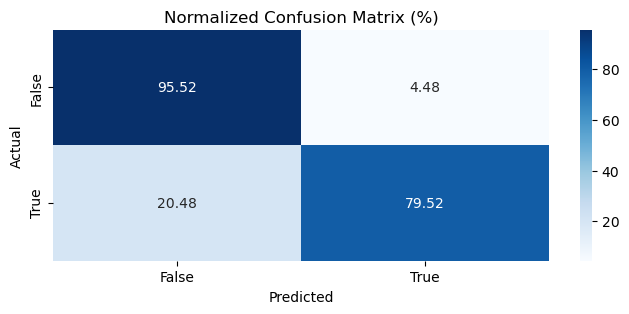

Cross-validation scores: [0.70911528 0.8150134  0.84316354 0.769437   0.85656836]
Mean cross-validation score: 0.7986595174262734


In [1450]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix

# Initialize the model
model = RandomForestClassifier(random_state=42)

# Fit the model
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)

# Evaluate the 
accuracy = accuracy_score(y_test, y_pred)  # Calculate accuracy
report = classification_report(y_test, y_pred)  # Generate classification report
conf_matrix = confusion_matrix(y_test, y_pred)  # Generate confusion matrix
conf_matrix_percent = conf_matrix.astype('float') / conf_matrix.sum(axis=1)[:, np.newaxis] * 100 # Normalize the confusion matrix to get percentages

# Print evaluation metrics
print("Accuracy:", accuracy)
print("\nClassification Report:\n", report)

# Visualize the normalized confusion matrix
plt.figure(figsize=(8, 3))
sns.heatmap(conf_matrix_percent, annot=True, fmt='.2f', cmap='Blues', 
            xticklabels=['False', 'True'], yticklabels=['False', 'True'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Normalized Confusion Matrix (%)')
plt.show()

# Cross-validate
from sklearn.model_selection import cross_val_score
# Define the number of folds for cross-validation
k = 5  # You can choose any number of folds, commonly 5 or 10
# Perform cross-validation
cv_scores = cross_val_score(model, X, y, cv=k)  # Evaluate the model using cross-validation
# Print the cross-validation scores
print("Cross-validation scores:", cv_scores)  # Display the scores for each fold
print("Mean cross-validation score:", cv_scores.mean())  # Print the mean score across all folds

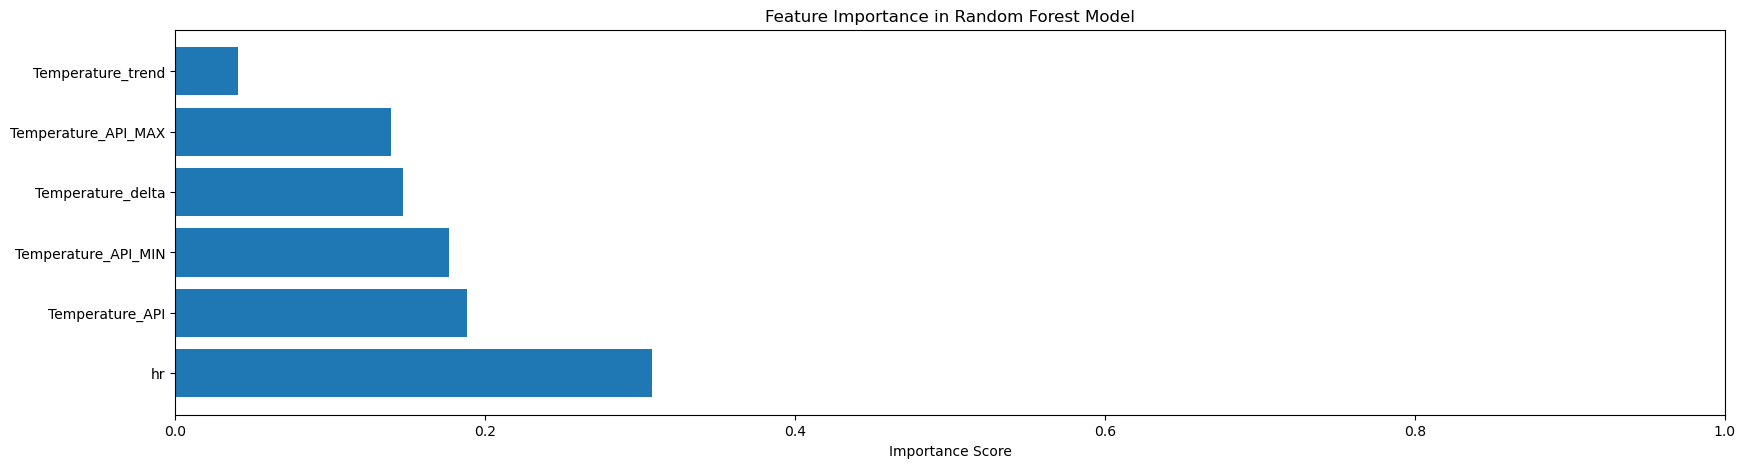

In [1452]:
#**Feature Importance**: Analyze the importance of each feature in the model to understand which variables are contributing the most to the predictions.
import matplotlib.pyplot as plt
import numpy as np

# Get feature importances from the model
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot the feature importances (flipped)
plt.figure(figsize=(20, 5))  # Adjust height for better visualization
plt.title("Feature Importance in Random Forest Model")
plt.barh(X.columns[indices], importances[indices], align="center")  # Use barh for horizontal bars
plt.xlabel("Importance Score")
plt.xlim([0, 1])  # Set x-axis limits to 0 and 1 for normalized importance scores
plt.show()

In [1394]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {
   'n_estimators': [100, 200, 300],
   'max_depth': [None, 10, 20, 30],
   'min_samples_split': [2, 5, 10],
   'min_samples_leaf': [1, 2, 4],
   # 'max_features': [1.0, 'sqrt', 'log2']
}

# Initialize GridSearchCV
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, cv=5, scoring='neg_mean_absolute_error', n_jobs=-1, verbose=2) # Set up the parameter grid
grid_search.fit(X_train, y_train) # Fit the grid search to the data

# Retrieve the best parameters and model
best_params = grid_search.best_params_
best_model = grid_search.best_estimator_

# Now you can use best_model to make predictions on your test data
y_pred = best_model.predict(X_test)

# Optionally, you can evaluate the model's performance
from sklearn.metrics import mean_absolute_error

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)  # Calculate R-squared value

print(f'MAE: {mae}, MSE: {mse}, R-squared: {r2}')  # Print the evaluation metrics including R-squared

# **Cross-Validation**: Instead of a single train-test split, use k-fold cross-validation to assess the model's performance more robustly. 
# This helps in understanding how the model generalizes to an independent dataset.
from sklearn.model_selection import cross_val_score

# Perform cross-validation
cv_scores = cross_val_score(best_model, X, y, cv=5, scoring='neg_mean_absolute_error')   # Use negative MAE for scoring
# Calculate the mean of the cross-validated scores and negate it to get the actual MAE
print(f'Cross-validated MAE: {-cv_scores.mean()}')  # Print the mean absolute error from cross-validation

Fitting 5 folds for each of 108 candidates, totalling 540 fits


C:\Users\20204113\AppData\Local\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:952: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(


TypeError: numpy boolean subtract, the `-` operator, is not supported, use the bitwise_xor, the `^` operator, or the logical_xor function instead.

## Save this model

In [1445]:
import joblib

# Save the trained models to disk
joblib.dump(model, 'model_action_window.pkl')  # Save the left light model

['model_action_window.pkl']